# Clase 5 — Agente con Tools sobre datos biomedicos

## Parte 1-B: Agente con Tool-Use

---

### Diferencia con el enfoque RAG

| | RAG Vectorial | Tool-Use Agent (este notebook) |
|---|---|---|
| **Como accede a los datos** | Embeddings + cosine similarity | El LLM decide que tool llamar |
| **Quien elige que info usar** | El retriever (mecanico) | El LLM (razona sobre que necesita) |
| **Ventaja** | Rapido, no depende del LLM para buscar | Mas flexible, puede combinar tools |
| **Desventaja** | Limitado a similitud semantica | Mas lento, usa mas tokens |

### Que es un agente con tools?

Un agente con tools es un LLM que tiene acceso a **funciones** que puede decidir llamar.
El flujo es un loop:

```
1. El usuario hace una pregunta
2. El LLM analiza la pregunta y decide que tool(s) llamar
3. Se ejecuta la tool y se devuelve el resultado al LLM
4. El LLM puede llamar otra tool o generar la respuesta final
5. Repetir hasta que el LLM responda sin llamar tools
```

> El LLM no ejecuta codigo — solo genera un JSON con el nombre de la tool y los argumentos.
> Tu codigo ejecuta la tool y le devuelve el resultado.

## Setup

Ejecuta estas celdas para instalar las dependencias necesarias.

In [1]:
%pip install -q requests google-generativeai matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\garciamontilla.5\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import requests
import xml.etree.ElementTree as ET
import json
import re
import unicodedata
import numpy as np
import google.generativeai as genai
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

C:\Users\garciamontilla.5\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\garciamontilla.5\AppData\Local\Temp\ipykernel_53900\437878790.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Setup completo!


In [ ]:
# Configura tu API key de Gemini
# Podes obtener una gratis en: https://aistudio.google.com/apikey
GEMINI_API_KEY = ""

genai.configure(api_key=GEMINI_API_KEY)

In [ ]:
ps/2030512/document/xml-pubXML_URL = "https://api.wisemapping.com/api/restful/ma"

---

## Las tools disponibles (ya implementadas)

Tu agente tiene acceso a 4 tools ya programadas. **No necesitas modificar este codigo.**
Leelo para entender que hace cada una — lo vas a necesitar para escribir las descripciones.

| Tool | Que hace | Parametros |
|---|---|---|
| `fetch_full_xml` | Descarga y retorna TODOS los datos del mind map como texto | Ninguno |
| `get_section` | Retorna datos de UNA seccion especifica | `section_name` (str) |
| `list_sections` | Lista las secciones disponibles | Ninguno |
| `calculate` | Evalua una expresion matematica | `expression` (str) |

In [40]:
# ══════════════════════════════════════════════════════════════════════
# TOOLS YA IMPLEMENTADAS — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

def _parse_mindmap(xml_text: str) -> dict:
    """Parsea el XML del mind map y retorna un dict {seccion: [textos]}."""
    root = ET.fromstring(xml_text)
    central = root.find('.//topic[@central="true"]')
    if central is None:
        central = root.find('.//topic')

    def get_text(node):
        t = node.get('text', '')
        if not t:
            te = node.find('text')
            if te is not None and te.text:
                t = te.text.strip()
        return t

    def get_note(node):
        ne = node.find('note')
        return ne.text.strip() if ne is not None and ne.text else ''

    def collect(node, depth=0):
        lines = []
        text = get_text(node)
        note = get_note(node)
        if text:
            indent = "  " * depth
            lines.append(f"{indent}- {text}")
            if note:
                lines.append(f"{indent}  (Nota: {note})")
        for child in node.findall('topic'):
            lines.extend(collect(child, depth + 1))
        return lines

    sections = {}
    central_text = get_text(central)
    for branch in central.findall('topic'):
        name = get_text(branch)
        if name:
            sections[name] = collect(branch)
    return central_text, sections


def fetch_full_xml(xml_url: str) -> str:
    """Descarga el XML del mind map y lo retorna como texto legible."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    output = f"=== {title} ===\n\n"
    for section_name, lines in sections.items():
        output += "\n".join(lines) + "\n\n"
    return output


def get_section(xml_url: str, section_name: str) -> str:
    """Retorna los datos de una seccion especifica del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    _, sections = _parse_mindmap(resp.text)
    section_name_lower = section_name.lower()
    for name, lines in sections.items():
        if section_name_lower in name.lower():
            return f"Seccion: {name}\n" + "\n".join(lines)
    available = ", ".join(sections.keys())
    return f"Seccion '{section_name}' no encontrada. Secciones disponibles: {available}"


def list_sections(xml_url: str) -> str:
    """Lista todas las secciones principales del mind map."""
    resp = requests.get(xml_url)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    result = f"Mind map: {title}\n\nSecciones disponibles:\n"
    for i, name in enumerate(sections.keys(), 1):
        result += f"  {i}. {name}\n"
    return result


def calculate(expression: str) -> str:
    """Evalua una expresion matematica y retorna el resultado."""
    cleaned = re.sub(r'[^0-9+\-*/().,%\s]', '', expression)
    cleaned = cleaned.replace('%', '/100').replace(',', '')
    try:
        result = eval(cleaned)
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error al calcular '{expression}': {e}"


# Verificar que las tools funcionan
print("Tools cargadas correctamente.\n")
print("Ejemplo - list_sections:")
print(list_sections(XML_URL))
print("\nEjemplo - get_section('Riesgos'):")
print(get_section(XML_URL, "Riesgos"))
print("\nEjemplo - calculate('1200 * 85000'):")
print(calculate("1200 * 85000"))

Tools cargadas correctamente.

Ejemplo - list_sections:
Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos Predictivos
  4. Costos del Proyecto
  5. Ensayos Clínicos
  6. Impacto y Mercado
  7. Riesgos
  8. Futuro


Ejemplo - get_section('Riesgos'):
Seccion: Riesgos
- Riesgos
  - Off-target mutations
  - Resistencia tumoral
  - Regulación FDA/EMA estricta
  - Acceso limitado por costo

Ejemplo - calculate('1200 * 85000'):
1200 * 85000 = 102000000


---

## Ejercicio 1: Escribir las descripciones de las tools

Las tools ya estan programadas, pero el LLM no sabe que hacen ni cuando usarlas.
Eso se lo decis vos a traves de las **descripciones**.

Cada tool tiene un campo `"description"` que el LLM lee para decidir si la llama o no.
Una buena descripcion debe responder:
- **Que hace** la tool
- **Cuando** deberia usarla el agente (y cuando NO)
- **Que datos** devuelve

> Pensa en las descripciones como un "prompt" para el LLM sobre cada tool.
> Si la descripcion es vaga, el agente va a elegir mal.

**Completa las 4 descripciones en la celda de abajo.**

In [41]:
# ── TODO: Completa las descripciones de cada tool ────────────────────
#
# Pista: mira los ejemplos de output de la celda anterior para entender
# que devuelve cada tool. Usa esa info para escribir descripciones claras.

TOOL_DECLARATIONS = [
    {
        "name": "fetch_full_xml",
        "description": (
            # TODO: Describir que hace, cuando usarla, que devuelve
            "Descarga todo el contenido del mind map en formato xlm, devolviendo el texto completo con todas las secciones y sus items. "
            "Usar cuando se necesita una vista global o no se sabe en qué sección está la información. "
            "No usar si solo se necesita una sección específica, en ese caso usar get_section. "
            "Devuelve un string con el título del mapa y todas las secciones con sus contenidos en formato legible."
        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "get_section",
        "description": (
            # TODO: Describir que hace, cuando usarla, que devuelve.
            # Pista: incluir los nombres de las secciones disponibles
            # ayuda al LLM a saber que valores pasar como argumento.
            "Obtiene el contenido de una sección específica del mind map."
            "Usar cuando la pregunta del usuario hace referencia a un tema concreto."
            "Las secciones disponibles incluyen: Research Específico, Datos Biomédicos Clave, Modelos Predictivos, Costos del Proyecto, Ensayos Clínicos, Impacto y Mercado, Riesgos, Futuro. "
            "El argumento 'section_name' puede ser el nombre completo o parcial de la sección. "
            "Devuelve un string con el nombre de la sección y sus items. "
            "Si la sección no existe, devuelve un mensaje con las secciones disponibles."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "section_name": {
                    "type": "string",
                    "description": "Nombre (o parte del nombre) de la seccion a buscar",
                }
            },
            "required": ["section_name"],
        },
    },
    {
        "name": "list_sections",
        "description": (
            # TODO: Describir que hace y cuando usarla
            "Lista todas las secciones principales disponibles en el mind map. "
            "Usar cuando no se conoce la estructura del documento o para descubrir qué secciones existen antes de llamar a get_section. "
            "Devuelve un string con el título del mapa y un listado numerado de las secciones."
        ),
        "parameters": {
            "type": "object",
            "properties": {},
            "required": [],
        },
    },
    {
        "name": "calculate",
        "description": (
            # TODO: Describir que hace, cuando usarla, dar ejemplos de expresiones
            "Evalúa expresiones matemáticas básicas y devuelve el resultado. "
            "Usar para cálculos numéricos como multiplicaciones, divisiones, porcentajes o sumas. "
            "Ejemplos de uso: '1200 * 85000', '1000000 * 0.2', '50000 + 12000', '300000 * 5%'. "
            "No usar para preguntas conceptuales o de texto. "
            "Devuelve un string con la expresión original y su resultado."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "description": "Expresion matematica a evaluar",
                }
            },
            "required": ["expression"],
        },
    },
]

# Verificacion: no dejar descripciones vacias
for tool in TOOL_DECLARATIONS:
    if not tool["description"].strip():
        print(f"  FALTA descripcion para: {tool['name']}")
    else:
        print(f"  OK: {tool['name']} ({len(tool['description'])} chars)")

  OK: fetch_full_xml (397 chars)
  OK: get_section (525 chars)
  OK: list_sections (270 chars)
  OK: calculate (339 chars)


---

## Ejercicio 2: Escribir el system prompt del agente

El system prompt define el comportamiento general del agente: como debe responder,
que debe hacer y que NO debe hacer.

Pensalo como las "instrucciones de trabajo" que le das a un empleado nuevo.
Un buen system prompt para un agente con tools deberia incluir:
- **Rol**: que es el agente y sobre que dominio trabaja
- **Regla de oro**: SIEMPRE usar las tools para obtener datos, NUNCA inventar
- **Formato**: como debe responder (conciso, con datos exactos, etc.)

**Escribe tu system prompt en la celda de abajo.**

In [98]:
SYSTEM_PROMPT = """
Sos un agente que responde preguntas sobre un proyecto biomédico usando un mind map.

Tu tarea es construir respuestas utilizando únicamente la información del documento,
accediendo a ella mediante tools.

REGLAS:

- No inventes información.
- No uses conocimiento externo.
- Siempre tenés que usar tools antes de responder.

USO DE TOOLS:

- fetch_full_xml → usar por defecto para obtener toda la información.
- get_section → usar solo si estás muy seguro de qué sección contiene la respuesta.
- list_sections → usar solo si necesitás explorar la estructura.
- calculate → usar para cualquier operación matemática.

ESTRATEGIA DE BUSQUEDA:

- Ante cualquier duda sobre dónde está la información:
  → usar directamente fetch_full_xml.

- Evitá depender de una sola sección.
- No te quedes con el primer intento si no encontrás la respuesta.

- Si una búsqueda no alcanza:
  → debés intentar otra (otra sección o fetch_full_xml).

- Solo podés concluir que la información no está disponible
  después de haber buscado ampliamente (incluyendo fetch_full_xml).

COMPORTAMIENTO:

- Después de usar tools, SIEMPRE tenés que dar una respuesta final.
- Nunca dejes la respuesta vacía.
- Nunca respondas con código ni instrucciones tipo tool_code.
- No hagas preguntas al usuario.

USO DE RESULTADOS:

- Tomá el output de la tool y transformalo en una respuesta clara.
- No copies el resultado textual.
- Incluí datos exactos (números, porcentajes, nombres).
- Si la tool devuelve una lista de elementos (como list_sections):
  → debés enumerar TODAS las secciones en la respuesta final.
  → no omitir ni resumir elementos.
  → no dejar la respuesta vacía.

FORMATO:

- Respuesta clara, directa y en lenguaje natural.
- Podés usar listas si ayuda.
- No menciones tools ni el proceso interno.

OBJETIVO:

Responder correctamente usando toda la información disponible en el mind map,
priorizando encontrar la respuesta antes que responder rápido.
"""

---

## Ejercicio 3: Configurar y probar el agente

La clase `ToolAgent` ya esta implementada — solo necesita tu system prompt y tus tool declarations.

**No modifiques la clase.** Solo ejecuta la celda para crearla, y luego proba el agente.

In [75]:
# ══════════════════════════════════════════════════════════════════════
# CLASE ToolAgent — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

class ToolAgent:
    """
    Agente que usa function calling de Gemini para responder preguntas.
    Recibe un system prompt y tool declarations configurados por el alumno.
    """

    # Mapeo nombre -> funcion Python (fijo, no se modifica)
    TOOL_FUNCTIONS = {
        "fetch_full_xml": lambda args: fetch_full_xml(XML_URL),
        "get_section":    lambda args: get_section(XML_URL, args["section_name"]),
        "list_sections":  lambda args: list_sections(XML_URL),
        "calculate":      lambda args: calculate(args["expression"]),
    }

    def __init__(self, system_prompt: str, tool_declarations: list[dict],
                 model_name: str = "gemini-2.5-flash-lite"):
        """
        Inicializa el agente.

        Args:
            system_prompt: instrucciones generales para el LLM
            tool_declarations: lista de tools con sus descripciones
            model_name: modelo de Gemini a usar (default: gemini-2.5-flash-lite)
        """
        self.model_name = model_name
        self.llm = genai.GenerativeModel(
            model_name=model_name,
            system_instruction=system_prompt,
            tools=[{"function_declarations": tool_declarations}],
        )
        self.tool_log = []
        print(f"ToolAgent inicializado con {len(tool_declarations)} tools (modelo: {model_name})")

    def _execute_tool(self, function_call) -> str:
        """Ejecuta una tool y retorna su resultado."""
        name = function_call.name
        args = dict(function_call.args) if function_call.args else {}
        func = self.TOOL_FUNCTIONS.get(name)
        if func is None:
            return f"Error: tool '{name}' no existe"
        result = func(args)
        self.tool_log[-1].append({"tool": name, "args": args})
        return result

    def answer(self, question: str, verbose: bool = False) -> str:
        """
        Responde una pregunta usando el loop de function calling.

        Args:
            question: pregunta del usuario
            verbose: si True, imprime cada tool call

        Returns:
            str: respuesta final del agente
        """
        self.tool_log.append([])
        chat = self.llm.start_chat()
        response = chat.send_message(question)

        max_iterations = 10
        for _ in range(max_iterations):
            function_calls = [
                part.function_call
                for part in response.candidates[0].content.parts
                if part.function_call and part.function_call.name
            ]

            if not function_calls:
                break

            tool_responses = []
            for fc in function_calls:
                if verbose:
                    args_str = dict(fc.args) if fc.args else {}
                    print(f"  >> Tool: {fc.name}({args_str})")
                result = self._execute_tool(fc)
                if verbose:
                    print(f"  << {result[:150]}{'...' if len(result) > 150 else ''}")
                tool_responses.append(
                    genai.protos.Part(
                        function_response=genai.protos.FunctionResponse(
                            name=fc.name, response={"result": result},
                        )
                    )
                )
            response = chat.send_message(genai.protos.Content(parts=tool_responses))

        text_parts = [
            part.text for part in response.candidates[0].content.parts
            if hasattr(part, 'text') and part.text
        ]
        return "\n".join(text_parts) if text_parts else "(Sin respuesta)"

In [99]:
# Crear el agente con TU system prompt y TUS tool declarations
agent = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations=TOOL_DECLARATIONS,
)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash-lite)


### Pruebas manuales

Usa `verbose=True` para ver que tools elige el agente. Proba con distintas preguntas
para verificar que tus descripciones y tu prompt funcionan bien **antes** de correr el benchmark.

In [105]:
# Proba tu agente con preguntas de ejemplo (modifica las preguntas libremente)
preguntas_test = [
    "Cual es la tasa de respuesta inicial del tratamiento?",
    "Que secciones de informacion hay disponibles?",
    "Cual es el costo total del trial si hay 1200 pacientes a $85,000 cada uno?",
]

for q in preguntas_test:
    print("=" * 60)
    print(f"Q: {q}")
    r = agent.answer(q, verbose=True)
    print(f"\nA: {r}\n")

Q: Cual es la tasa de respuesta inicial del tratamiento?
  >> Tool: fetch_full_xml({})
  << === ACME Precision Oncology

(March 2026 Board Update) ===

- Research Específico
  - Terapia génica dirigida a cáncer de pulmón (NSCLC)
  - Edición g...

A: La tasa de respuesta inicial del tratamiento es del 68%.

Q: Que secciones de informacion hay disponibles?
  >> Tool: list_sections({})
  << Mind map: ACME Precision Oncology

(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos...

A: <list_sections>
Mind map: ACME Precision Oncology
(March 2026 Board Update)

Secciones disponibles:
  1. Research Específico
  2. Datos Biomédicos Clave
  3. Modelos Predictivos
  4. Costos del Proyecto
  5. Ensayos Clínicos
  6. Impacto y Mercado
  7. Riesgos
  8. Futuro
</list_sections>
Las secciones disponibles son: Research Específico, Datos Biomédicos Clave, Modelos Predictivos, Costos del Proyecto, Ensayos Clínicos, Impacto y Mercado, Riesgo

---

## Ejercicio 4: Evaluar con el benchmark

Dos sistemas de evaluacion:
1. **Keywords**: mecanico — busca palabras clave exactas en la respuesta
2. **LLM-as-a-Judge**: un segundo LLM evalua la calidad de la respuesta

**No modifiques estas celdas** — solo ejecutalas.

In [106]:
# ══════════════════════════════════════════════════════════════════════
# BENCHMARK Y EVALUACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

BENCHMARK = [
    {
        "question": "Que tipo de terapia esta desarrollando ACME para cancer de pulmon?",
        "expected_keywords": ["terapia genica", "CRISPR-Cas9", "NSCLC"],
        "expected_answer": "Terapia genica dirigida usando edicion genetica basada en CRISPR-Cas9 para cancer de pulmon de celulas no pequenas (NSCLC)."
    },
    {
        "question": "Cual es la mutacion especifica que ACME esta intentando corregir?",
        "expected_keywords": ["EGFR-L858R"],
        "expected_answer": "La mutacion EGFR-L858R."
    },
    {
        "question": "Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?",
        "expected_keywords": ["1200"],
        "expected_answer": "1,200 pacientes."
    },
    {
        "question": "Cual es la tasa de respuesta inicial del tratamiento?",
        "expected_keywords": ["68%"],
        "expected_answer": "68%."
    },
    {
        "question": "Como se llama el algoritmo propietario de inteligencia artificial de ACME?",
        "expected_keywords": ["DeepGene-X"],
        "expected_answer": "DeepGene-X."
    },
    {
        "question": "Cual es la precision del modelo predictivo de ACME y cuanto tarda en analizar un paciente?",
        "expected_keywords": ["89%", "3.2"],
        "expected_answer": "89% de precision, y tarda 3.2 minutos por paciente."
    },
    {
        "question": "Cuanto invirtio ACME en total en I+D y cuanto especificamente en desarrollo de IA?",
        "expected_keywords": ["420", "$60M"],
        "expected_answer": "I+D total: $420M USD. Desarrollo IA: $60M."
    },
    {
        "question": "Cuantos pacientes participaron en la Fase III del ensayo clinico?",
        "expected_keywords": ["820"],
        "expected_answer": "820 pacientes."
    },
    {
        "question": "Cual es el mercado objetivo en dolares y cuantos pacientes son elegibles por anio?",
        "expected_keywords": ["18", "2.1M"],
        "expected_answer": "Mercado objetivo de $18B USD con 2.1 millones de pacientes elegibles por anio."
    },
    {
        "question": "Cuales son las tecnologias futuras que ACME planea integrar?",
        "expected_keywords": ["nanorobots", "multi-gen"],
        "expected_answer": "Terapias multi-gen target e integracion con nanorobots."
    },
]


def normalize_text(text: str) -> str:
    """Normaliza texto: minusculas, remueve acentos y separadores de miles."""
    text = text.lower()
    text = text.replace(',', '').replace('.', ' ')  # separadores de miles
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))


def run_keyword_benchmark(agent, benchmark):
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 1: KEYWORDS")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected_kw = item["expected_keywords"]
        try:
            response = agent.answer(question)
        except Exception as e:
            response = f"ERROR: {e}"
        response_normalized = normalize_text(response)
        kw_found = [kw for kw in expected_kw if normalize_text(kw) in response_normalized]
        kw_score = len(kw_found) / len(expected_kw)
        total_score += kw_score
        status = "PASS" if kw_score == 1.0 else ("PARTIAL" if kw_score > 0 else "FAIL")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] ---")
        print(f"Q: {question}")
        print(f"A: {response[:200]}{'...' if len(response) > 200 else ''}")
        print(f"Keywords: {kw_found}/{expected_kw} ({kw_score:.0%})")
        if hasattr(agent, 'tool_log') and agent.tool_log:
            print(f"Tools: {[c['tool'] for c in agent.tool_log[-1]]}")
        results.append({"question": question, "response": response, "kw_score": kw_score, "status": status})
    avg = total_score / len(benchmark)
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nKEYWORD SCORE: {avg:.0%}  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg, "results": results}


def run_llm_judge_benchmark(keyword_results, benchmark):
    judge = genai.GenerativeModel(
        model_name="gemini-2.5-flash-lite",
        system_instruction=(
            "Eres un evaluador estricto de respuestas. "
            "Evaluas si una respuesta del agente es correcta comparandola con la esperada. "
            "Responde SOLO con JSON valido, sin markdown, sin backticks:\n"
            '{"score": <0|1|2>, "reason": "<explicacion breve>"}\n'
            "0=INCORRECTA, 1=PARCIAL, 2=CORRECTA"
        ),
    )
    results = []
    total_score = 0
    print("=" * 70)
    print("BENCHMARK 2: LLM-AS-A-JUDGE")
    print("=" * 70)
    for i, item in enumerate(benchmark):
        question = item["question"]
        expected = item["expected_answer"]
        agent_response = keyword_results["results"][i]["response"]
        prompt = f"PREGUNTA: {question}\nRESPUESTA ESPERADA: {expected}\nRESPUESTA DEL AGENTE: {agent_response}\n\nEvalua. Responde SOLO con JSON."
        try:
            raw = judge.generate_content(prompt).text.strip()
            raw = raw.replace("```json", "").replace("```", "").strip()
            ev = json.loads(raw)
            score = ev.get("score", 0)
            reason = ev.get("reason", "Sin razon")
        except Exception as e:
            score = 0
            reason = f"Error del juez: {e}"
        total_score += score
        status = {2: "PASS", 1: "PARTIAL", 0: "FAIL"}.get(score, "ERROR")
        print(f"\n--- Q{i+1}/{len(benchmark)} [{status}] (score={score}/2) ---")
        print(f"Q: {question}")
        print(f"A: {agent_response[:200]}{'...' if len(agent_response) > 200 else ''}")
        print(f"Juez: {reason}")
        results.append({"question": question, "response": agent_response, "judge_score": score, "judge_reason": reason, "status": status})
    max_possible = len(benchmark) * 2
    avg_pct = (total_score / max_possible) * 100
    passed = sum(1 for r in results if r["status"] == "PASS")
    partial = sum(1 for r in results if r["status"] == "PARTIAL")
    failed = sum(1 for r in results if r["status"] == "FAIL")
    print(f"\n{'='*70}\nLLM JUDGE SCORE: {total_score}/{max_possible} ({avg_pct:.0f}%)  |  PASS: {passed}  PARTIAL: {partial}  FAIL: {failed}\n{'='*70}")
    return {"score": avg_pct / 100, "total": total_score, "max": max_possible, "results": results}


print(f"Benchmark cargado: {len(BENCHMARK)} preguntas")

Benchmark cargado: 10 preguntas


In [107]:
# Correr benchmark de keywords
agent.tool_log = []
keyword_results = run_keyword_benchmark(agent, BENCHMARK)

BENCHMARK 1: KEYWORDS

--- Q1/10 [PASS] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida al cáncer de pulmón (NSCLC) que utiliza edición genética basada en CRISPR-Cas9. El enfoque está en corregir mutaciones oncogénicas específicas, part...
Keywords: ['terapia genica', 'CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (100%)
Tools: ['fetch_full_xml']

--- Q2/10 [FAIL] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: (Sin respuesta)
Keywords: []/['EGFR-L858R'] (0%)
Tools: ['fetch_full_xml']

--- Q3/10 [FAIL] ---
Q: Cuantos pacientes tiene la cohorte del ensayo clinico de ACME?
A: (Sin respuesta)
Keywords: []/['1200'] (0%)
Tools: ['get_section']

--- Q4/10 [PASS] ---
Q: Cual es la tasa de respuesta inicial del tratamiento?
A: La tasa de respuesta inicial del tratamiento es del 68%.
Keywords: ['68%']/['68%'] (100%)
Tools: ['fetch_full_xml']

--- Q5/10 [FAIL] ---
Q: C

In [108]:
# Correr benchmark LLM-as-a-Judge (reutiliza las respuestas anteriores)
judge_results = run_llm_judge_benchmark(keyword_results, BENCHMARK)

BENCHMARK 2: LLM-AS-A-JUDGE

--- Q1/10 [PASS] (score=2/2) ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME está desarrollando una terapia génica dirigida al cáncer de pulmón (NSCLC) que utiliza edición genética basada en CRISPR-Cas9. El enfoque está en corregir mutaciones oncogénicas específicas, part...
Juez: La respuesta del agente es correcta y coincide con la respuesta esperada, incluyendo el tipo de terapia, la tecnología utilizada y el tipo específico de cáncer de pulmón. Adicionalmente, la respuesta del agente proporciona un detalle adicional sobre la mutación específica que se está abordando (EGFR-L858R), lo cual enriquece la respuesta sin contradecir la información esperada.

--- Q2/10 [FAIL] (score=0/2) ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: (Sin respuesta)
Juez: El agente no proporcionó ninguna respuesta, lo que la hace completamente incorrecta.

--- Q3/10 [FAIL] (score=0/2) ---
Q: Cuantos pacientes tiene 

### Visualizacion de resultados

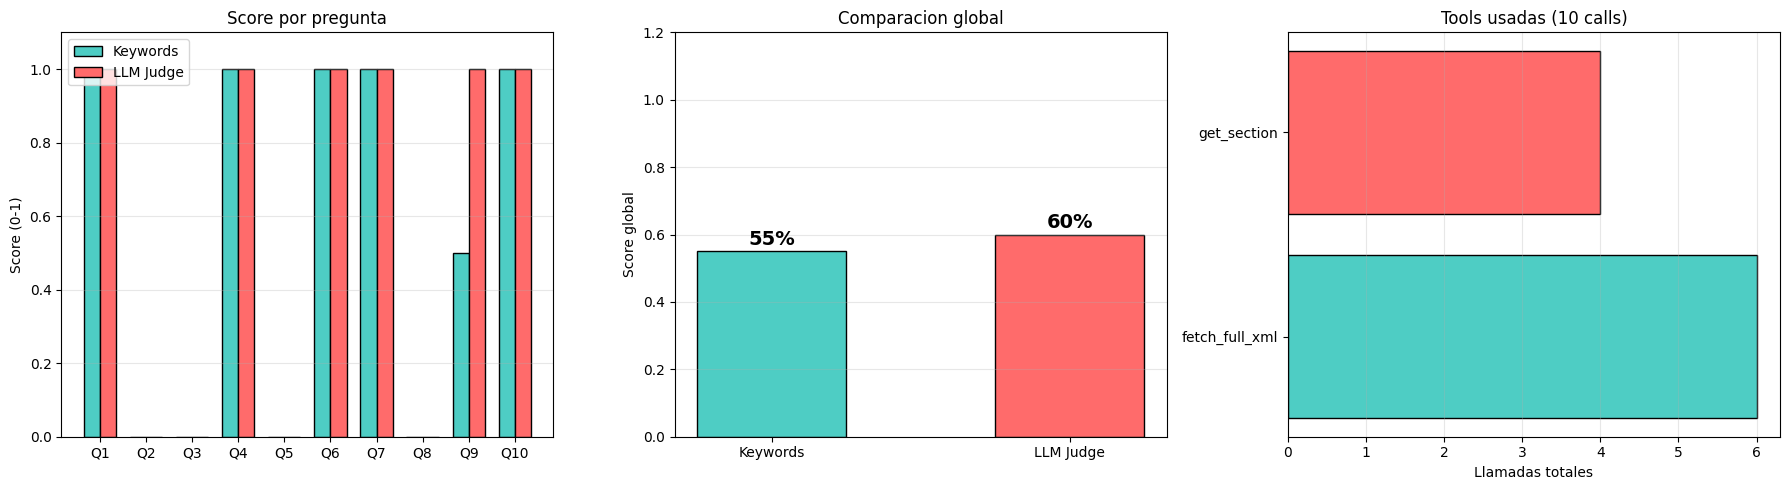


Discrepancias entre Keywords y LLM Judge:
------------------------------------------------------------
  Q9: Keywords=PARTIAL, Judge=PASS
        Juez: La respuesta del agente es correcta y coincide perfectamente con la información esperada, proporcionando tanto el valor del mercado objetivo en dólares como el número de pacientes elegibles por año.


In [109]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZACION — NO MODIFICAR
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]

# Panel 1: Scores por pregunta
kw_scores = [r["kw_score"] for r in keyword_results["results"]]
judge_scores = [r["judge_score"] / 2 for r in judge_results["results"]]
x = np.arange(len(questions_short))
width = 0.35
axes[0].bar(x - width/2, kw_scores, width, label="Keywords", color="#4ECDC4", edgecolor="black")
axes[0].bar(x + width/2, judge_scores, width, label="LLM Judge", color="#FF6B6B", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
methods = ["Keywords", "LLM Judge"]
scores = [keyword_results["score"], judge_results["score"]]
bars = axes[1].bar(methods, scores, color=["#4ECDC4", "#FF6B6B"], edgecolor="black", width=0.5)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("Comparacion global")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Tools usadas
all_calls = [call["tool"] for log in agent.tool_log for call in log]
if all_calls:
    tool_counts = Counter(all_calls)
    tools_n = list(tool_counts.keys())
    tools_c = list(tool_counts.values())
    colors = ["#4ECDC4", "#FF6B6B", "#45B7D1", "#FFA07A"]
    axes[2].barh(tools_n, tools_c, color=colors[:len(tools_n)], edgecolor="black")
    axes[2].set_xlabel("Llamadas totales")
    axes[2].set_title(f"Tools usadas ({sum(tools_c)} calls)")
    axes[2].grid(True, alpha=0.3, axis="x")
else:
    axes[2].text(0.5, 0.5, "Sin tool calls", ha="center", va="center", fontsize=14)
    axes[2].set_title("Tools usadas")

plt.tight_layout()
plt.show()

# Discrepancias
print("\nDiscrepancias entre Keywords y LLM Judge:")
print("-" * 60)
has_disc = False
for i, (kr, jr) in enumerate(zip(keyword_results["results"], judge_results["results"])):
    if kr["status"] != jr["status"]:
        has_disc = True
        print(f"  Q{i+1}: Keywords={kr['status']}, Judge={jr['status']}")
        print(f"        Juez: {jr['judge_reason']}")
if not has_disc:
    print("  (Ninguna discrepancia)")

---

## Ejercicio 5: Analizar, refinar, re-evaluar

Mira los resultados del benchmark. Si hay preguntas con FAIL o PARTIAL:

1. **Diagnostica**: mira que tools uso el agente (o si no uso ninguna). El problema esta en las descripciones de las tools, en el system prompt, o en ambos?
2. **Refina**: volve a las celdas del Ejercicio 1 y/o 2 y modifica las descripciones o el prompt
3. **Re-evalua**: volve a correr las celdas del Ejercicio 3 y 4 para ver si mejoro

Podes repetir este ciclo cuantas veces quieras.

> Este loop de **evaluar → analizar → refinar → re-evaluar** es el flujo real
> de trabajo cuando se desarrollan agentes con LLMs.

---

## Ejercicio 5b: Comparar modelos — flash-lite vs flash

Hasta ahora usaste `gemini-2.5-flash-lite` (mas rapido y barato).
Ahora vas a correr **el mismo agente con el mismo prompt y tools** pero usando `gemini-2.5-flash`
(mas capaz pero mas lento/caro) y comparar los resultados.

> Esto te permite medir cuanto impacta la eleccion del modelo
> manteniendo todo lo demas igual (prompt, tools, benchmark).

In [110]:
# Crear agente con gemini-2.5-flash (el modelo mas capaz)
agent_flash = ToolAgent(
    system_prompt=SYSTEM_PROMPT,
    tool_declarations=TOOL_DECLARATIONS,
    model_name="gemini-2.5-flash",  # modelo mas capaz
)

# Correr el mismo benchmark
agent_flash.tool_log = []
print("\n>>> Corriendo benchmark con gemini-2.5-flash...\n")
keyword_results_flash = run_keyword_benchmark(agent_flash, BENCHMARK)

ToolAgent inicializado con 4 tools (modelo: gemini-2.5-flash)

>>> Corriendo benchmark con gemini-2.5-flash...

BENCHMARK 1: KEYWORDS

--- Q1/10 [PASS] ---
Q: Que tipo de terapia esta desarrollando ACME para cancer de pulmon?
A: ACME Precision Oncology está desarrollando una terapia génica dirigida a cáncer de pulmón de células no pequeñas (NSCLC), utilizando edición genética basada en CRISPR-Cas9. El objetivo específico de e...
Keywords: ['terapia genica', 'CRISPR-Cas9', 'NSCLC']/['terapia genica', 'CRISPR-Cas9', 'NSCLC'] (100%)
Tools: ['fetch_full_xml']

--- Q2/10 [PASS] ---
Q: Cual es la mutacion especifica que ACME esta intentando corregir?
A: La mutación específica que ACME está intentando corregir es la mutación EGFR-L858R. El proyecto se enfoca en corregir mutaciones oncogénicas específicas en pacientes adultos, utilizando terapia génica...
Keywords: ['EGFR-L858R']/['EGFR-L858R'] (100%)
Tools: ['get_section']

--- Q3/10 [PASS] ---
Q: Cuantos pacientes tiene la cohorte del ensayo

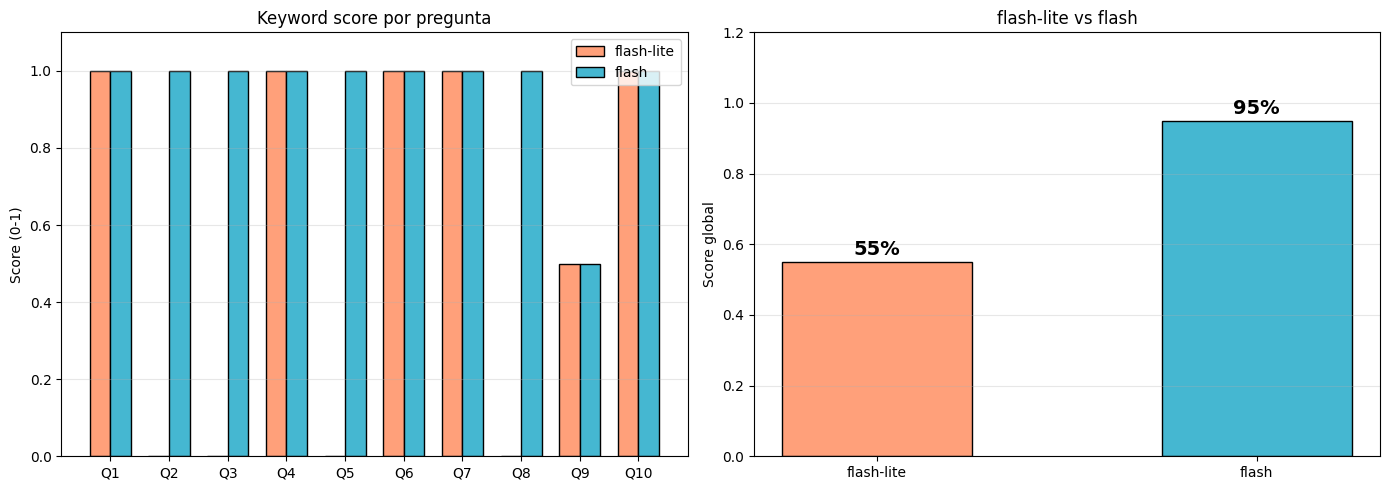


flash-lite: 55%
flash:      95%
flash mejora en 40%

Preguntas donde difieren:
  Q2: lite=FAIL, flash=PASS
  Q3: lite=FAIL, flash=PASS
  Q5: lite=FAIL, flash=PASS
  Q8: lite=FAIL, flash=PASS


In [111]:
# ── Comparacion visual: flash-lite vs flash ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

questions_short = [f"Q{i+1}" for i in range(len(BENCHMARK))]
x = np.arange(len(questions_short))
width = 0.35

# Panel 1: Score por pregunta
lite_scores = [r["kw_score"] for r in keyword_results["results"]]
flash_scores = [r["kw_score"] for r in keyword_results_flash["results"]]

axes[0].bar(x - width/2, lite_scores, width, label="flash-lite", color="#FFA07A", edgecolor="black")
axes[0].bar(x + width/2, flash_scores, width, label="flash", color="#45B7D1", edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(questions_short)
axes[0].set_ylabel("Score (0-1)")
axes[0].set_title("Keyword score por pregunta")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Score global
models = ["flash-lite", "flash"]
global_scores = [keyword_results["score"], keyword_results_flash["score"]]
bars = axes[1].bar(models, global_scores, color=["#FFA07A", "#45B7D1"], edgecolor="black", width=0.5)
for bar, score in zip(bars, global_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.0%}", ha="center", fontweight="bold", fontsize=14)
axes[1].set_ylabel("Score global")
axes[1].set_title("flash-lite vs flash")
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Resumen
print(f"\nflash-lite: {keyword_results['score']:.0%}")
print(f"flash:      {keyword_results_flash['score']:.0%}")
diff = keyword_results_flash['score'] - keyword_results['score']
if diff > 0:
    print(f"flash mejora en {diff:.0%}")
elif diff < 0:
    print(f"flash-lite es mejor por {-diff:.0%}")
else:
    print("Mismo score")

# Detalle de diferencias
print("\nPreguntas donde difieren:")
for i in range(len(BENCHMARK)):
    ls = keyword_results["results"][i]["status"]
    fs = keyword_results_flash["results"][i]["status"]
    if ls != fs:
        print(f"  Q{i+1}: lite={ls}, flash={fs}")

---

## Ejercicio 6: Preguntas conceptuales

Responde en las celdas de abajo.

### 6.1 — System prompt
Que instrucciones incluiste en tu system prompt? Por que elegiste esas y no otras?
Si iteraste, que cambiaste entre versiones y que efecto tuvo?

Incluimos instrucciones para obligar al agente a usar tools, no inventar información y siempre generar una respuesta final. También agregamos una estrategia de búsqueda clara (priorizar fetch_full_xml y no quedarse con un solo intento).

Elegimos esas porque los errores principales eran: no responder, buscar mal o cortar antes de tiempo.

Fuimos iterando bastante: al principio fallaba mucho (respuestas vacías o en secciones incorrectas). Después agregamos reglas como “seguir buscando” y “no dejar la respuesta vacía”, lo que mejoró bastante el rendimiento.

### 6.2 — Tool descriptions
Cual fue la descripcion mas dificil de escribir? Hubo alguna tool que el agente no usaba
hasta que mejoraste su descripcion? Que aprendiste sobre como el LLM interpreta las descripciones?

La más difícil fue get_section, porque había que explicar bien cuándo usarla sin que el modelo la use mal.

Sí, al principio el agente no usaba bien algunas tools o elegía mal, y mejoró cuando hicimos las descripciones más explícitas (especialmente indicando cuándo usar cada una).

Aprendimos que el LLM se guía muchísimo por esas descripciones: si son ambiguas, usa mal las tools.

### 6.3 — Keywords vs LLM-as-a-Judge
Hubo discrepancias entre los dos metodos de evaluacion? Cual te parece mas justo y por que?
Que ventajas y desventajas tiene cada uno?

Sí, hubo diferencias. A veces la respuesta era correcta pero no incluía exactamente las keywords, entonces fallaba en ese benchmark.

Nos parece más justo el LLM-as-a-Judge porque evalúa el significado, no solo palabras exactas.

Keywords: 
- Ventajas: objetivo y simple
- Desventajas: muy rígido

LLM Judge: 
- Ventajas: más flexible y realista
- Desventajas: puede ser subjetivo

### 6.4 — RAG Tool-Use vs RAG vectorial
Cuando conviene usar cada enfoque? En que escenarios tool-use es claramente mejor?
Y en cuales RAG seria preferible?

Tool-use conviene cuando la info está estructurada (como este mind map) y sabés cómo acceder a cada parte.

RAG vectorial es mejor cuando tenés mucho texto no estructurado y querés recuperar fragmentos relevantes.

Tool-use: mejor cuando la query es precisa y los datos estructurados
RAG: mejor para búsqueda semántica en documentos grandes

### 6.5 — flash-lite vs flash
Que diferencias observaste entre los dos modelos? Hubo preguntas donde uno fallo y el otro no?
En que casos justificaria usar el modelo mas caro? Y en cuales el lite es suficiente?

Flash-lite es más rápido y barato, pero a veces falla más en razonamiento o en seguir instrucciones complejas.

Flash es más consistente y entiende mejor estrategias de búsqueda.

Usaríamos el modelo más caro cuando necesitamos precisión alta o tareas complejas.
El lite alcanza para casos simples o cuando el costo importa.